### Step 1: Load the exported ML dataset

This cell loads the CSV file exported from Hive/HDFS into a pandas DataFrame, assigns meaningful column names, and previews the first few rows to confirm the structure.


In [1]:
import pandas as pd

df = pd.read_csv(
    "amazon_reviews_ml_features.csv",
    header=None
)

df.columns = [
    "star_rating",
    "helpful_votes",
    "total_votes",
    "verified_purchase",
    "review_length"
]

df.head()

,star_rating,helpful_votes,total_votes,verified_purchase,review_length
0,3,0,1,N,43
1,5,0,0,Y,38
2,3,0,1,Y,28
3,5,0,0,Y,131
4,5,0,0,Y,23


### Step 2: Create the target label and encode categories

This cell creates a binary sentiment target (`positive_review`) from `star_rating` (e.g., 4–5 stars as positive) and encodes `verified_purchase` into numeric form for modelling.


In [2]:
# Binary sentiment label
df["positive_review"] = df["star_rating"].apply(
    lambda x: 1 if x >= 4 else 0
)

# Encode verified purchase
df["verified_purchase"] = df["verified_purchase"].map({"Y": 1, "N": 0})

### Step 3: Visualise the rating distribution

This cell plots a histogram of `star_rating` to understand class balance and overall rating skew before modelling.


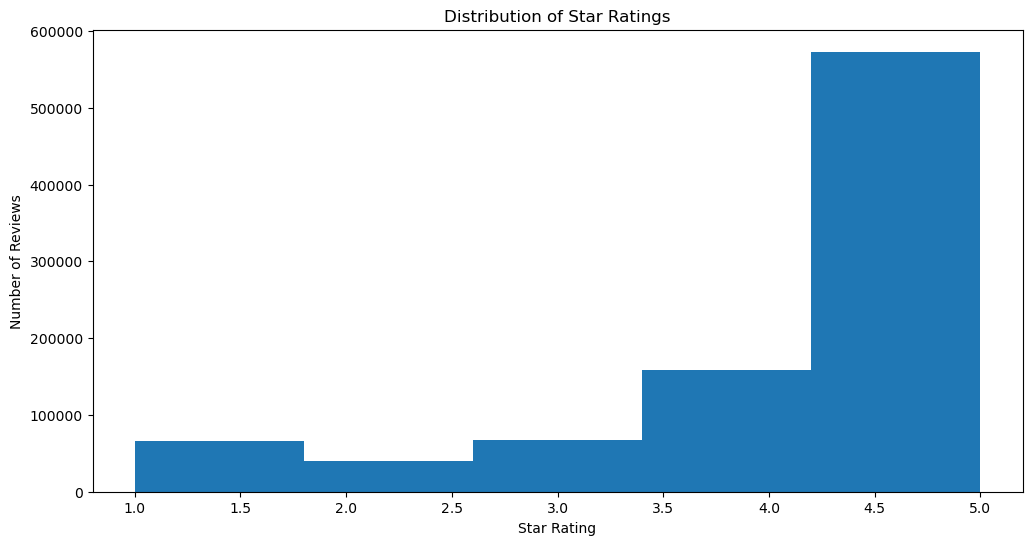

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(df["star_rating"], bins=5)
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Star Ratings")
plt.show()


### Step 4: Compare review length across rating levels

This cell uses a boxplot to examine how `review_length` varies by `star_rating`, helping to validate whether review structure differs between low and high ratings.


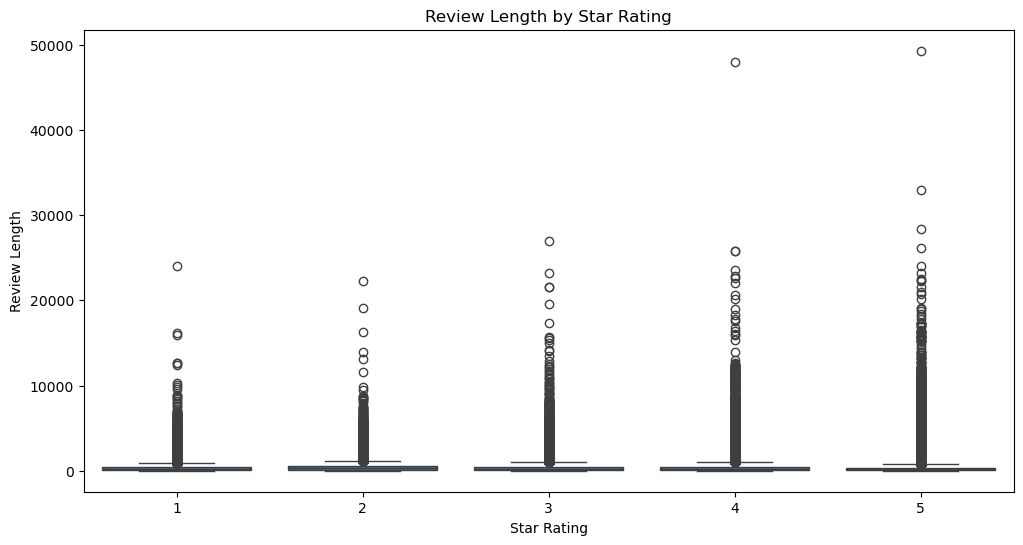

In [4]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x="star_rating", y="review_length", data=df)
plt.xlabel("Star Rating")
plt.ylabel("Review Length")
plt.title("Review Length by Star Rating")
plt.show()


### Step 5: Prepare features and split the data

This cell defines the feature matrix `X` and target `y`, performs an 80/20 train–test split, and standardises numeric features using `StandardScaler` to support stable model training.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features = ["review_length", "helpful_votes", "total_votes", "verified_purchase"]
X = df[features]
y = df["positive_review"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Step 6: Train a Logistic Regression classifier

This cell trains a Logistic Regression model to classify reviews as positive vs non-positive based on engineered features (length, votes, verified purchase).


In [6]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Step 7: Evaluate classification performance

This cell generates predictions on the test set and prints precision, recall, F1-score, and support to assess how well the classifier distinguishes positive and non-positive reviews.


In [7]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.09      0.17     34421
           1       0.82      0.99      0.90    146532

    accuracy                           0.82    180953
   macro avg       0.77      0.54      0.53    180953
weighted avg       0.80      0.82      0.76    180953



### Step 8: Plot the confusion matrix

This cell visualises the confusion matrix as a heatmap to show true positives, true negatives, false positives, and false negatives in an interpretable format.


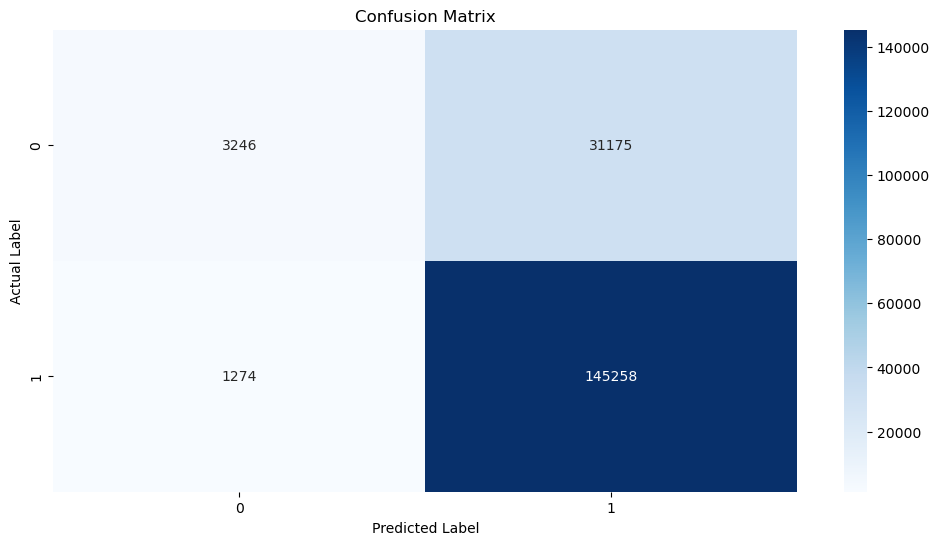

In [8]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()


### Step 9: Prepare features for clustering

This cell selects numeric variables for unsupervised segmentation and standardises them so that variables with larger scales do not dominate cluster formation.


In [9]:
from sklearn.preprocessing import StandardScaler

cluster_features = df[["review_length", "helpful_votes", "total_votes", "star_rating"]]
cluster_features = cluster_features.fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)


### Step 10: Fit K-Means and assign cluster labels

This cell runs K-Means clustering (k=3 for interpretability) and assigns each review to a cluster, enabling segment-level analysis of review behaviour.


In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

### Step 11: Visualise clusters using PCA

This cell reduces the scaled feature space to two principal components using PCA and plots the clusters to assess separation and overlap between segments.


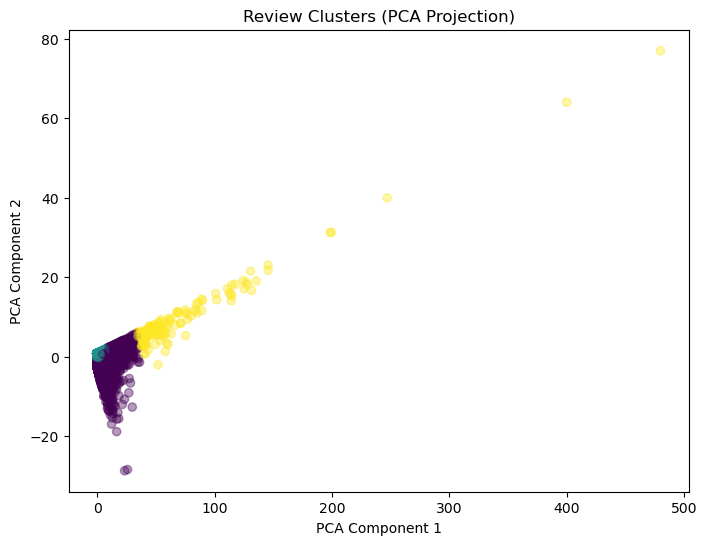

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"], alpha=0.4)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Review Clusters (PCA Projection)")
plt.show()